# Проверка гипотезы об однородности результатов экзамена по математике у студентов, прошедших и не прошедших подготовительный курс.

Успеваемость студентов может зависеть от множетсва факторов, в том числе из-за дополнительной подготовке перед экзаменами.

Нужно проверить утверждение: можно ли считать выборки результатов экзамена по математике студентов, прошедших и не прошедших подготовительный курс, однородными?. Т.о. значима ли статистически прохождение подготовительного курса для результатов экзамена 

Источник данных: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams. В задании данные можно найти в фале StudentsPerformance.csv.

Для решения задачи будет использоваться 
- t-критерий Стьюдента
- критерий Манна—Уитни

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from math import sqrt

### Описание датасета 

In [2]:
students = pd.read_csv('StudentsPerformance.csv')
students.head(5)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


- gender - пол
- race/ethnicity - раса/этнос
- parental level of education - уровень образования родителей
- test preparation course - прохождение подготовительного курса. Прошел - completed, не прошел - none
- math score — балл за экзамен по математике

### Формулировка гипотез
- H₀: выборки однородны: в среднем баллы по математике студентов обеих групп одинаковы
- H₁: выборки неоднородны: в среднем баллы различаются

### Валидация данных

In [3]:
# Проверка на пропуски 
students.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [4]:
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
students.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### Формирование выборок

In [6]:
completed = students[students['test preparation course'] == 'completed']['math score'].values
none = students[students['test preparation course'] == 'none']['math score'].values

print('')
display(completed)
print('-'*10)

print('\nОценки учеников по Математике, НЕ прошедшихкурс')
display(none)

array([ 69,  88,  64,  78,  46,  65,  74,  81,  75,  59,  55,  57,  82,
        77,  71,  82,  58,  79,  58,  63,  80,  61,  50,  43,  78,  65,
        63,  68,  60,  98,  66,  77,  99,  79,  91,  88,  65,  53,  87,
        75,  74,  51,  71,  42,  68, 100,  62,  59,  70,  66,  61,  82,
        75,  96,  53,  58,  68,  67,  72,  43,  81,  46,  71,  52,  97,
        62,  45,  65,  62,  76,  77,  69,  59,  67,  74,  81,  80,  60,
        87,  84,  83,  61,  56,  52,  88,  83,  64,  73,  58,  47,  60,
        78,  65,  64,  79,  88,  88,  85,  59,  70,  81,  97,  77,  63,
        78,  46,  71,  40,  81,  67,  74,  99,  67,  68,  59,  77,  67,
        82,  62,  76,  35,  69,  67,  77,  63,  42,  85,  49,  69,  45,
        82,  85,  87,  73,  57,  65,  59,  88,  65,  52,  87,  70,  84,
        63,  51,  71,  57,  82,  57,  47,  59,  50,  89,  67,  67,  86,
        64,  72,  75,  72,  77,  83,  68,  90,  71,  76,  73,  64,  79,
        68,  59,  94,  95,  54,  77,  76,  66,  66,  67,  53,  5

----------

Оценки учеников по Математике, НЕ прошедшихкурс


array([ 72,  90,  47,  76,  71,  40,  38,  58,  40,  65,  50,  69,  88,
        18,  54,  66,  44,  69,  73,  69,  67,  70,  62,  69,  63,  56,
        40,  97,  74,  50,  57,  55,  58,  53,  50,  65,  66,  53,  53,
        88,  33,  52,   0,  39,  62,  69,  59,  67,  45,  60,  61,  39,
        41,  61,  49,  44,  30,  62,  47,  49,  72,  42,  73,  76,  71,
        58,  73,  65,  27,  71,  79,  58,  65,  79,  85,  58,  87,  52,
        70,  62,  54,  51,  84,  75,  78,  51,  55,  63,  83,  87,  72,
        82,  51,  89,  58,  70,  59,  76,  59,  57,  88,  22,  88,  73,
        77,  54,  62,  60,  66,  49,  52,  81,  94,  79,  63,  46,  50,
        65,  80,  48,  77,  66,  62,  61,  55,  45,  78,  65,  69,  57,
        59,  82,  74,  58,  35,  42,  34,  66,  87,  55,  86,  45,  72,
        57,  68,  76,  46,  67,  92,  80,  63,  54,  84,  80,  56,  59,
        75,  85,  89,  65,  68,  71,  80,  54,  62,  64,  70,  44,  99,
        76,  59,  63,  69,  71,  69,  58,  47,  65,  83,  65,  7

### Описательная статистика

In [7]:
print('Среднее completed:', completed.mean())
print('Среднее none:', none.mean())

print('Медиана completed:', np.median(completed))
print('Медиана none:', np.median(none))

Среднее completed: 69.69553072625699
Среднее none: 64.0778816199377
Медиана completed: 69.0
Медиана none: 64.0


In [8]:
def variance(x):
    'Расчет выборочной дисперсии'
    m = mean(x)
    return sum((i - m) ** 2 for i in x) / (len(x) - 1)

In [9]:
def mean(x):
    'Расчет среднего значения'
    return sum(x) / len(x)

### T-критерий Стьюдента
- Среднее значение: x̄ = (1/n) Σxi
- Выборочная дисперсия: S² = (1/(n−1)) Σ(xi − x̄)²
- Объединённая дисперсия: sp² = ((n₁−1)S₁² + (n₂−1)S₂²)/(n₁+n₂−2)
- Статистика критерия: t = (x̄₁ − x̄₂) / √(sp²(1/n₁ + 1/n₂))

In [10]:
n1 = len(completed)
n2 = len(none)

mean1 = mean(completed)
mean2 = mean(none)

var1 = variance(completed)
var2 = variance(none)

sp2 = ((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2)

# t-статистика
t = (mean1 - mean2) / sqrt(sp2 * (1/n1 + 1/n2))
alpha = 0.05 # Уровень значимости
t_critical = 1.96 # При alpha = 0.05 - t_critical ≈ 1.96

print('t-statistic =', t)

print('alpha =', alpha)
print('t-critical =', t_critical)

if abs(t) > t_critical:
    print('Гипотеза H0 отвергается')
else:
    print('Нет оснований отвергать H0')

t-statistic = 5.704616417349102
alpha = 0.05
t-critical = 1.96
Гипотеза H0 отвергается


### Критерий Манна—Уитни
U₁ = n₁n₂ + n₁(n₁+1)/2 − R₁ где R₁ — сумма рангов первой группы.Аналогично вычисляется U₂.

Итоговая U-статистика: U = min(U₁, U₂)

In [11]:
combined = []
alpha = 0.05
z_critical = 1.96

for value in completed:
    combined.append((value, 0))

for value in none:
    combined.append((value, 1))

combined.sort(key=lambda x: x[0])

ranks = []

for i, item in enumerate(combined):
    ranks.append((item[0], item[1], i + 1))

R1 = 0
R2 = 0

for value, group, rank in ranks:
    if group == 0:
        R1 += rank
    else:
        R2 += rank

U1 = n1 * n2 + (n1 * (n1 + 1)) / 2 - R1
U2 = n1 * n2 + (n2 * (n2 + 1)) / 2 - R2

U = min(U1, U2)

print('U-statistic =', U)


print('alpha =', alpha)

mu_U = n1 * n2 / 2

sigma_U = sqrt(n1 * n2 * (n1 + n2 + 1) / 12)

z = (U - mu_U) / sigma_U

print('z-statistic =', z)
print('z-critical =', z_critical)

if abs(z) > z_critical:
    print('Гипотеза H0 отвергается')
else:
    print('Нет оснований отвергать H0')

U-statistic = 93573.0
alpha = 0.05
z-statistic = -4.874843929048216
z-critical = 1.96
Гипотеза H0 отвергается


### Итог
Оба критерия показали наличие статистически значимых различий между выборками -> подготовительный курс оказывает статистически значимое влияние на результаты экзамена по математике 

Ниже для наглядности представлен график для визуализации распределния данных

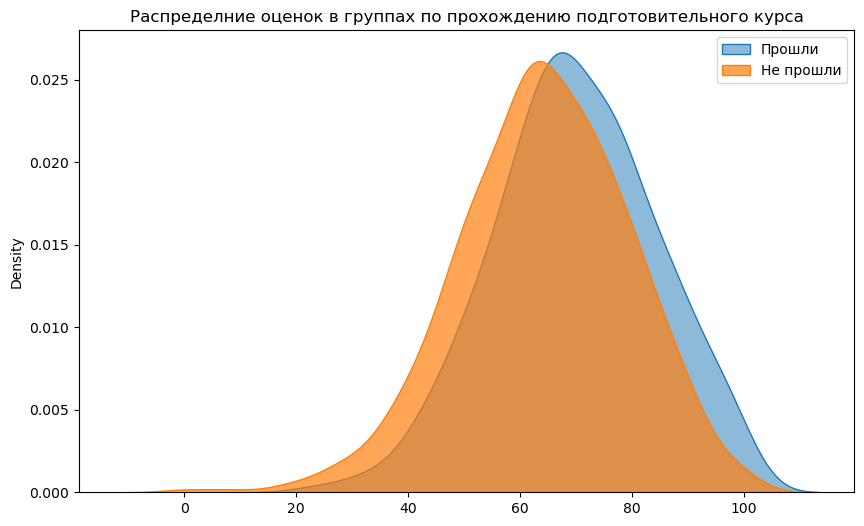

In [24]:
plt.figure(figsize=(10,6))
plt.title('Распределние оценок в группах по прохождению подготовительного курса')
sns.kdeplot(completed, fill=True, alpha=0.5, label='Прошли')
sns.kdeplot(none, fill=True, alpha=0.7, label='Не прошли')
plt.legend()
plt.show()